In [153]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

data_dir = Path("../data")
paths = sorted(data_dir.glob("*_vac.csv")) + sorted(data_dir.glob("*_air.csv"))

# Load all traces once (time in µs, voltage flipped)
t_list = []
v_list = []

for path in paths:
    t, v = np.loadtxt(path, delimiter=",", unpack=True)
    t_list.append(t)
    v_list.append(-v)

# Optional sanity check:
paths

[WindowsPath('../data/1_vac.csv'),
 WindowsPath('../data/2_vac.csv'),
 WindowsPath('../data/3_vac.csv'),
 WindowsPath('../data/4_vac.csv'),
 WindowsPath('../data/5_vac.csv'),
 WindowsPath('../data/1_air.csv'),
 WindowsPath('../data/2_air.csv'),
 WindowsPath('../data/3_air.csv'),
 WindowsPath('../data/4_air.csv'),
 WindowsPath('../data/5_air.csv')]

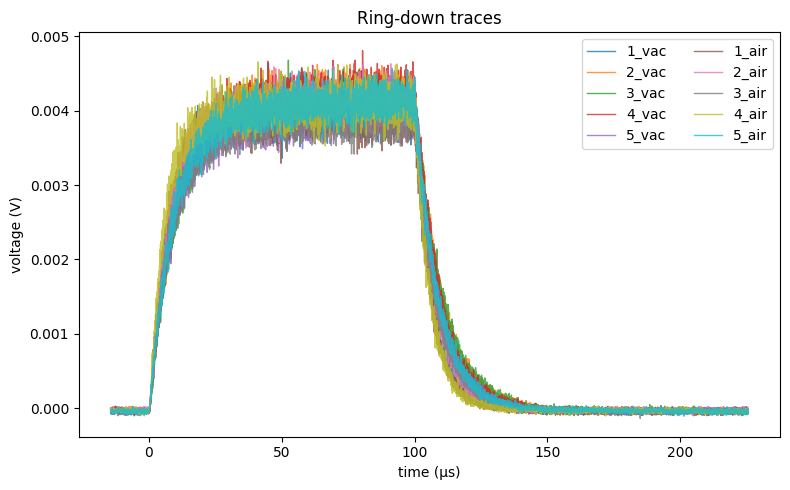

In [154]:
plt.figure(figsize=(8,5))
for i, path in enumerate(paths):
    t = t_list[i] * 1e6  # s -> µs (plot only)
    v = v_list[i]
    plt.plot(t, v, label=path.stem, linewidth=1, alpha=0.8)

plt.xlabel("time (μs)")
plt.ylabel("voltage (V)")
plt.title("Ring-down traces")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [155]:
# for i, path in enumerate(paths):
#     t = t_list[i] * 1e6
#     v = v_list[i]
#     plt.figure(figsize=(8,4))
#     plt.plot(t, v)
#     plt.title(path.stem)
#     plt.xlabel("time (μs)")
#     plt.ylabel("voltage (V)")
#     plt.tight_layout()
#     plt.show()

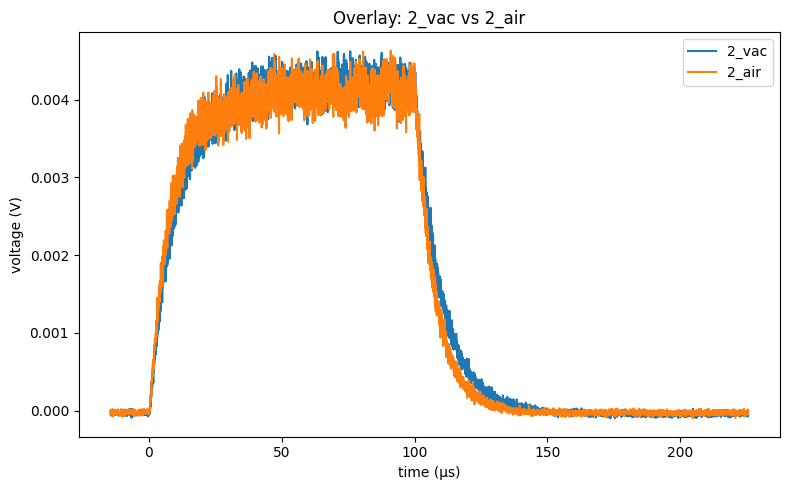

In [156]:
idxs = [1, 6]  # pair of measurements x_vac and x_air

plt.figure(figsize=(8,5))
for i in idxs:
    t = t_list[i] * 1e6
    v = v_list[i]
    plt.plot(t, v, label=paths[i].stem)

plt.title(f"Overlay: {paths[idxs[0]].stem} vs {paths[idxs[1]].stem}")
plt.xlabel("time (μs)")
plt.ylabel("voltage (V)")
plt.legend()
plt.tight_layout()
plt.show()

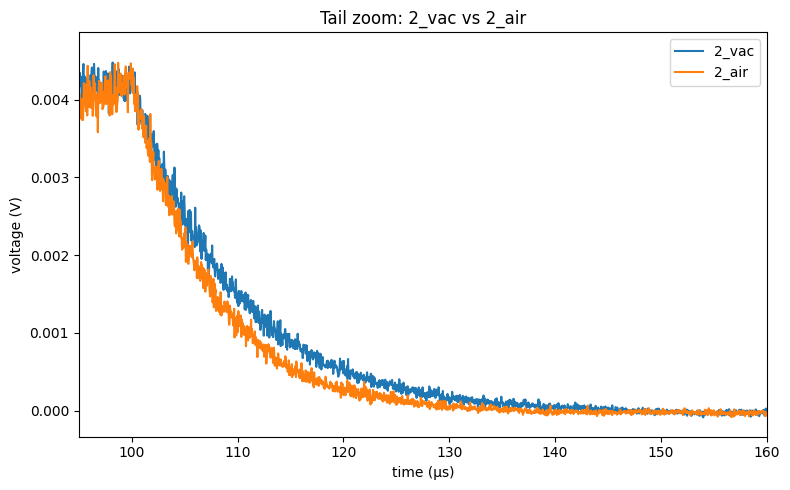

In [157]:
plt.figure(figsize=(8,5))
for i in idxs:
    t = t_list[i] * 1e6
    v = v_list[i]
    plt.plot(t, v, label=paths[i].stem)

plt.xlim(95, 160)
plt.title(f"Tail zoom: {paths[idxs[0]].stem} vs {paths[idxs[1]].stem}")
plt.xlabel("time (μs)")
plt.ylabel("voltage (V)")
plt.legend()
plt.tight_layout()
plt.show()

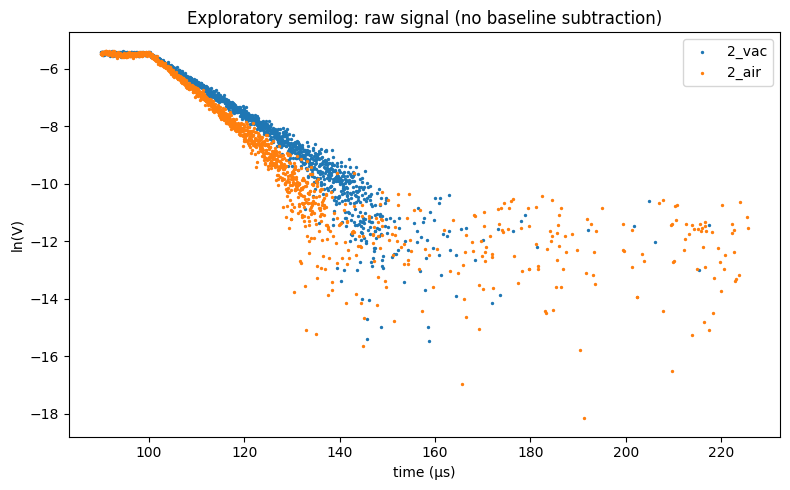

In [ ]:
plt.figure(figsize=(8,5))

for i in idxs:
    t = t_list[i]
    v = v_list[i]
    t_us = t * 1e6

    # Wide view: include a bit before pulse end to justify t_start,
    # and go all the way into the noise region.
    mask = (t_us >= 90)

    # For the log plot we can only use positive values (late times can cross zero due to noise)
    plt.scatter(t_us[mask][v[mask] > 0], np.log(v[mask][v[mask] > 0]),
                s=2, label=paths[i].stem)

plt.xlabel("time (µs)")
plt.ylabel("ln(V)")
plt.title("Exploratory semilog: raw signal (no baseline subtraction)")
plt.legend()
plt.tight_layout()
plt.show()

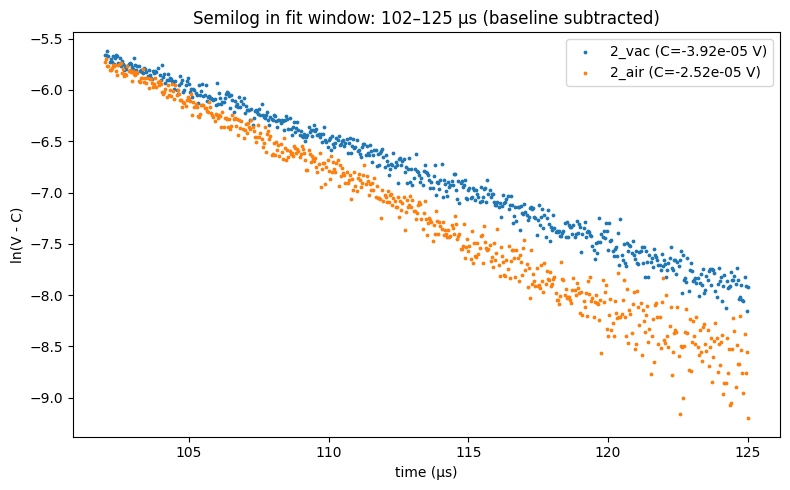

In [ ]:
t_start = 102
t_end = 125
t_noise = 160

plt.figure(figsize=(8,5))

for i in idxs:
    t = t_list[i]
    v = v_list[i]
    t_us = t * 1e6

    # Baseline offset C: average late-time region where the ring-down has decayed (signal ≈ noise)
    C = np.mean(v[t_us >= t_noise])

    # Start of ring-down: laser pulse lasts ~100 µs, so for t_us >= 100 µs the cavity is no longer pumped, conservatively choose 102
    mask = (t_us >= t_start) & (t_us <= t_end)

    # y is the ring-down signal above the baseline: V(t) - C  ∝  exp(-t/τ)
    y = v[mask] - C

    plt.scatter(t_us[mask][y > 0], np.log(y[y > 0]),
                s=3, label=f"{paths[i].stem} (C={C:.2e} V)")

plt.xlabel("time (µs)")
plt.ylabel("ln(V - C)")
plt.title(f"Semilog in fit window: {t_start}–{t_end} µs (baseline subtracted)")
plt.legend()
plt.tight_layout()
plt.show()

---